**Step 1: Dataset Preparation and Exploratory Data Analysis (EDA)**
In this step, we aim to:

* Load the Banking77 dataset.

* Understand the distribution of intents.

* Explore sentence lengths and vocabulary size.

* Prepare the text for tokenization using the DistilBERT tokenizer.

Understanding the dataset and vocabulary is critical before we build a model. It helps us identify preprocessing requirements, validate class balance, and choose model hyperparameters such as sequence length and embedding dimensions.

**Step 1.1: Install Required Libraries**

In [ ]:
!pip install transformers datasets evaluate gensim faiss-cpu rouge_score scikit-learn nltk torch seaborn matplotlib
!pip install --upgrade numpy==1.26.1
!pip install --upgrade pandas==2.1.0
!pip install --upgrade gensim
!pip install optuna


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.5 MB/s eta 0:00:00
   ━━

In [ ]:
!pip install --upgrade datasets==2.16.0 huggingface_hub transformers

  Using cached datasets-2.16.0-py3-none-any.whl.metadata (20 kB)
  Using cached huggingface_hub-0.31.4-py3-none-any.whl.metadata (13 kB)
  Using cached transformers-4.52.3-py3-none-any.whl.metadata (40 kB)
Using cached datasets-2.16.0-py3-none-any.whl (507 kB)
Using cached huggingface_hub-0.31.4-py3-none-any.whl (489 kB)
Using cached transformers-4.52.3-py3-none-any.whl (10.5 MB)
  Attempting uninstall: transformers
    Found existing installation: transformers 4.51.3
    Uninstalling transformers-4.51.3:
      Successfully uninstalled transformers-4.51.3
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4


In [ ]:
import nltk
import random
nltk.download('punkt_tab')
from datasets import load_dataset, concatenate_datasets,  Dataset, DatasetDict
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
from transformers import DistilBertTokenizerFast
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import re
from sklearn.model_selection import train_test_split
import os




**Step 1.2: Load the Banking77 Dataset**
We use Hugging Face's datasets library to directly load the banking77 dataset, which contains real banking-related customer queries annotated with 77 different intent classes.

In [ ]:
# Load the BANKING77 dataset
banking_dataset = load_dataset("banking77")

# Concatenate train and test splits
dataset = concatenate_datasets([banking_dataset["train"], banking_dataset["test"]])

# Verify the combined dataset
print(dataset)
print(f"Total number of samples: {len(dataset)}")


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3080 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label'],
    num_rows: 13083
})
Total number of samples: 13083


 **Step 1.3: Visualize Dataset Structure
to look at a few examples to understand what the queries and intent labels look like.**

In [ ]:
random.seed(42)
for i in random.sample(range(len(dataset)), 5):
    print(f"Example {i}")
    print("Text   :", dataset[i]['text'])
    print("Intent :", dataset[i]['label'])
    print("-" * 60)


Example 10476
Text   : I believe my credit card was stolen.
Intent : 41
------------------------------------------------------------
Example 1824
Text   : Can you tell me the cost of a transfer?
Intent : 56
------------------------------------------------------------
Example 409
Text   : I think something went wrong with my exchange between Russian Ruble and UK pounds. I was overcharged during the swap.
Intent : 17
------------------------------------------------------------
Example 12149
Text   : May I receive a different card pin
Intent : 21
------------------------------------------------------------
Example 4506
Text   : I see some transactions that I don't recognize.  I think someone stole my details.
Intent : 22
------------------------------------------------------------


**Step 1.4: Visualize the Intent Distribution**
Before modeling, we check if the dataset is balanced across all 77 intent classes. We'll plot a histogram to visualize how samples are distributed across these classes

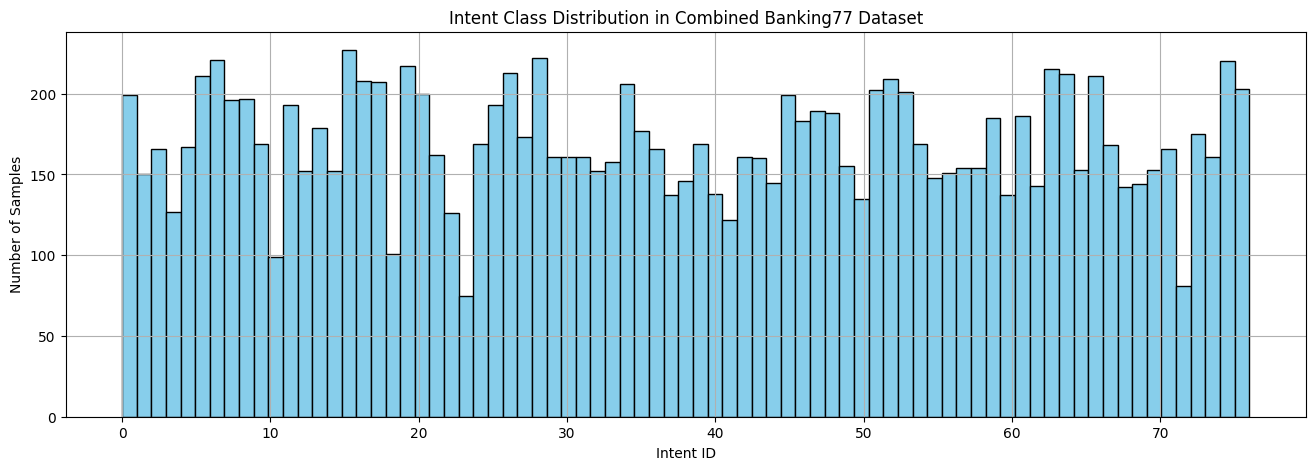

In [ ]:
label_counts = Counter(dataset['label'])

plt.figure(figsize=(16,5))
plt.hist(dataset['label'], bins=77, color='skyblue', edgecolor='black')
plt.title("Intent Class Distribution in Combined Banking77 Dataset")
plt.xlabel("Intent ID")
plt.ylabel("Number of Samples")
plt.grid(True)
plt.show()


**Step 1.5: Load and Inspect Intent Label Names**

In [ ]:
label_names = dataset.features['label'].names
print(f"Total unique intents: {len(label_names)}\n")

# first 10 intent names
for i, label in enumerate(label_names[:10]):
    print(f"{i:2}: {label}")


Total unique intents: 77

 0: activate_my_card
 1: age_limit
 2: apple_pay_or_google_pay
 3: atm_support
 4: automatic_top_up
 5: balance_not_updated_after_bank_transfer
 6: balance_not_updated_after_cheque_or_cash_deposit
 7: beneficiary_not_allowed
 8: cancel_transfer
 9: card_about_to_expire


**Step 1.6: Analyze Tokenized Sentence Lengths Using DistilBERT Tokenizer**

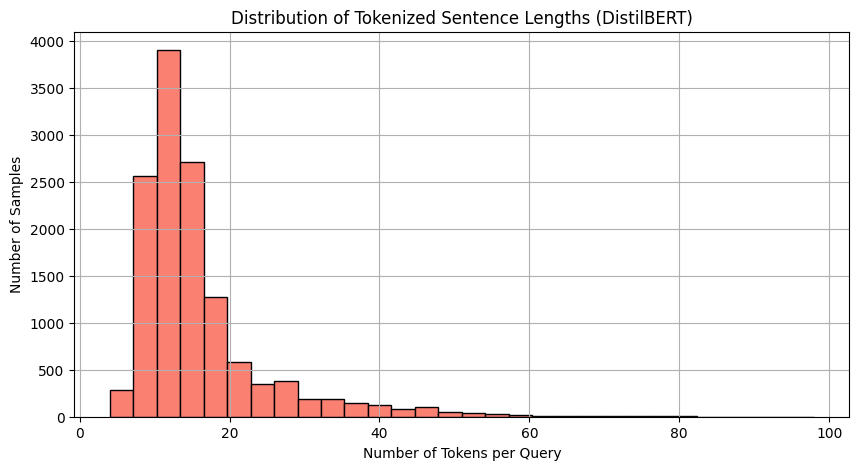

Average token length : 15.94
Max token length     : 98
90th percentile      : 26


In [ ]:
# Load tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# Tokenize and get length of each sentence
token_lengths = [len(tokenizer.encode(text, truncation=True)) for text in dataset['text']]

# histogram of token lengths
plt.figure(figsize=(10,5))
plt.hist(token_lengths, bins=30, color='salmon', edgecolor='black')
plt.title("Distribution of Tokenized Sentence Lengths (DistilBERT)")
plt.xlabel("Number of Tokens per Query")
plt.ylabel("Number of Samples")
plt.grid(True)
plt.show()

# summary stats
print(f"Average token length : {np.mean(token_lengths):.2f}")
print(f"Max token length     : {np.max(token_lengths)}")
print(f"90th percentile      : {np.percentile(token_lengths, 90):.0f}")


**Step 1.7: Build Word-Level Vocabulary**



In [ ]:
vocab = defaultdict(int)

for text in dataset['text']:
    # Basic tokenization and lowercasing
    tokens = re.findall(r'\b\w+\b', text.lower())
    for token in tokens:
        vocab[token] += 1

# vocabulary stats
print(f"Total unique words (raw vocab): {len(vocab)}")

#top 20 most frequent tokens
sorted_vocab = sorted(vocab.items(), key=lambda x: x[1], reverse=True)
print("\nTop 20 frequent tokens:")
for word, freq in sorted_vocab[:20]:
    print(f"{word:<10} : {freq}")


Total unique words (raw vocab): 2554

Top 20 frequent tokens:
i          : 11292
my         : 7409
to         : 5188
a          : 4547
the        : 4475
card       : 3591
is         : 3048
can        : 2753
it         : 2584
do         : 2492
how        : 2039
for        : 2019
t          : 2001
what       : 1999
up         : 1759
why        : 1737
account    : 1716
you        : 1566
and        : 1541
money      : 1407


**Step 2: Stratified Data Splitting**
We use stratified splitting to ensure all 77 intents are proportionally represented across all subsets.

To effectively train, validate, and evaluate our custom LLM (with and without RAG), we divide the 13,083 samples into 4 parts:

Training Set (45%) — for training the base model.

FAISS Support Set (10%) — indexed for retrieval in Few-Shot RAG.

Validation Set (20%) — for hyperparameter tuning and early stopping.

Test Set (25%) — kept completely unseen for final evaluation.

In [ ]:
#Hugging Face dataset to a DataFrame
df = dataset.to_pandas()

# First split: 45% train, 55% remaining
train_df, remaining_df = train_test_split(
    df,
    test_size=0.55,
    stratify=df['label'],
    random_state=42
)

# Second split: 10% FAISS, 45% remaining
faiss_df, remaining_df = train_test_split(
    remaining_df,
    test_size=(45/55),
    stratify=remaining_df['label'],
    random_state=42
)

# Third split: 20% validation, 25% test (from remaining 45%)
valid_df, test_df = train_test_split(
    remaining_df,
    test_size=(25/45),
    stratify=remaining_df['label'],
    random_state=42
)

# back to Hugging Face datasets
train_dataset = Dataset.from_pandas(train_df)
faiss_dataset = Dataset.from_pandas(faiss_df)
valid_dataset = Dataset.from_pandas(valid_df)
test_dataset  = Dataset.from_pandas(test_df)

# DatasetDict
custom_dataset = DatasetDict({
    'train': train_dataset,
    'faiss': faiss_dataset,
    'validation': valid_dataset,
    'test': test_dataset
})

for split in custom_dataset:
    print(f"{split:<10} → {len(custom_dataset[split]):>5} samples")

save_path = "/content/custom_dataset_splits"

os.makedirs(save_path, exist_ok=True)

# Save the DatasetDict to the specified path
custom_dataset.save_to_disk(save_path)

print(f"\nDataset saved to: {save_path}")


train      →  5887 samples
faiss      →  1308 samples
validation →  2616 samples
test       →  3272 samples


Saving the dataset (0/1 shards):   0%|          | 0/5887 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1308 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2616 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3272 [00:00<?, ? examples/s]


Dataset saved to: /content/custom_dataset_splits


**Step 3: Tokenization and Preprocessing**

We need to convert raw text into token IDs and attention masks compatible with our MiniLLM’s input. This includes:

Using the DistilBERT tokenizer for consistent token IDs.

Padding or truncating sequences to a fixed max length (30 tokens).

Preparing input batches with attention masks.

Ensuring labels are intact for classification.

Tokenizes each text into input_ids and attention_mask.

Pads or truncates sequences to length 30 tokens.

Removes the original raw text column for memory efficiency.

Sets the dataset format to PyTorch tensors for seamless training.

We need to prepare the raw text into numerical format (input_ids and attention_masks) that a transformer-based custom LLM can understand. We use a pretrained tokenizer (DistilBERTTokenizerFast) even though we’ll train our own model weights — this gives us clean and consistent subword tokenization across all samples.



In [ ]:
# Load tokenizer once
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

max_length = 30  # Based on our EDA analysis

def tokenize_and_encode(example):
    # Tokenize text with padding/truncation to max_length
    encoding = tokenizer(
        example['text'],
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_attention_mask=True
    )
    return encoding

# Apply tokenization to each split
for split in ['train', 'validation', 'faiss', 'test']:
    print(f"Tokenizing {split} split...")
    custom_dataset[split] = custom_dataset[split].map(
        tokenize_and_encode,
        batched=True,
        remove_columns=['text']
    )

custom_dataset.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'label']
)

print(custom_dataset['train'][0])


Tokenizing train split...


Map:   0%|          | 0/5887 [00:00<?, ? examples/s]

Tokenizing validation split...


Map:   0%|          | 0/2616 [00:00<?, ? examples/s]

Tokenizing faiss split...


Map:   0%|          | 0/1308 [00:00<?, ? examples/s]

Tokenizing test split...


Map:   0%|          | 0/3272 [00:00<?, ? examples/s]

{'label': tensor(67), 'input_ids': tensor([ 101, 2129, 2574, 2097, 1045, 2156, 1996, 4651, 1999, 2026, 4070, 1029,
         102,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0])}


**Preprocessing: Tokenization and Label Encoding**

This section focuses on preparing our dataset for training a DistilBERT model.
We'll perform two key preprocessing steps
* label encoding to convert categorical labels into numerical representations
* tokenization to convert our text data into a format that the DistilBERT model can understand.




In [ ]:
# Step 1: Load tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
max_length = 30  # Based on our EDA analysis

# Step 4: Tokenization function
def tokenize_and_encode(example):
    return tokenizer(
        example['text'],
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_attention_mask=True
    )

# Step 5: Apply tokenization
for split in ['train', 'validation', 'faiss', 'test']:
    print(f"Tokenizing {split} split...")
    # Check if 'text' column exists before mapping
    if 'text' in custom_dataset[split].features:
        custom_dataset[split] = custom_dataset[split].map(
            tokenize_and_encode,
            batched=True,
            remove_columns=['text']
        )
    else:
        print(f"Skipping tokenization for {split} split: 'text' column not found.")
         # Ensure required columns are present if skipping tokenization
        if not all(col in custom_dataset[split].features for col in ['input_ids', 'attention_mask', 'label']):
              raise ValueError(f"Split {split} is missing required columns after skipping tokenization.")


# Step 6: Format for PyTorch
custom_dataset.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'label']
)

# Step 7: Confirm sample
print(custom_dataset['train'][0])

Tokenizing train split...
Skipping tokenization for train split: 'text' column not found.
Tokenizing validation split...
Skipping tokenization for validation split: 'text' column not found.
Tokenizing faiss split...
Skipping tokenization for faiss split: 'text' column not found.
Tokenizing test split...
Skipping tokenization for test split: 'text' column not found.
{'label': tensor(67), 'input_ids': tensor([ 101, 2129, 2574, 2097, 1045, 2156, 1996, 4651, 1999, 2026, 4070, 1029,
         102,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0])}


**Step 4: Building the Custom MiniLLM architecture and training on this tokenized data**

We now define a custom lightweight transformer-based model (MiniLLM) to classify intents from user queries in the Banking77 dataset.
This model is trained from scratch — no pretrained weights — to serve as a strong baseline before adding retrieval mechanisms


In [ ]:
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import optuna
from sentence_transformers import SentenceTransformer
import faiss
import random
import json

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load tokenizer and model
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
vocab_size = len(tokenizer.vocab)

In [ ]:
class MiniLLM(nn.Module):
    def __init__(self, vocab_size, hidden_size=512, num_classes=77, max_len=30, num_heads=8, num_layers=3, dropout=0.3):
        super(MiniLLM, self).__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=hidden_size)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=num_heads,
            batch_first=True,
            dropout=dropout
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        x = self.transformer(x, src_key_padding_mask=~attention_mask.bool())
        x = x.mean(dim=1)
        x = self.dropout(x)
        logits = self.classifier(x)
        return logits


**Step 5: Evaluate the Trained MiniLLM on the Test Set**

Model Training with Early Stopping and Class-Weighted Loss
In this section, we will perform the training of our MiniLLM model. To ensure robust performance and prevent common pitfalls like overfitting, we'll implement several key strategies:

* Class-Weighted Loss: We will address any potential class imbalance within our training data. By using class weights in our loss function, we'll assign higher penalties for misclassifications of less frequent classes, ensuring the model learns effectively across all categories.
Learning Rate Scheduling: To optimize the model's convergence, we will employ a learning rate scheduler. This will dynamically adjust the learning rate during training, allowing the model to make appropriate sized steps towards the optimal solution.
* Early Stopping: This is a crucial technique to prevent overfitting. We will monitor the model's performance on a dedicated validation set and halt training if the validation loss doesn't show improvement for a specified number of epochs. This ensures we capture the model at its best generalization capability.
* Model Saving: We will save the model's state at a predefined epoch (Epoch 7) and also keep track of and save the best-performing model based on its validation loss. This provides us with multiple checkpoints of our model's progress.


In [ ]:
vocab_size_int = len(tokenizer.vocab)
# Passed the integer vocabulary size to the MiniLLM constructor
model = MiniLLM(vocab_size=vocab_size_int).to(device)
train_df = custom_dataset['train'].to_pandas()
class_counts = train_df['label'].value_counts()
total_samples = len(train_df)
vocab_size_int = len(tokenizer.vocab)
model = MiniLLM(vocab_size=vocab_size_int).to(device)
class_weights = torch.tensor([total_samples / (len(class_counts) * count) for count in class_counts.sort_index().values], dtype=torch.float).to(device)

# Step 3: Training with Early Stopping and Class-Weighted Loss
train_loader = DataLoader(custom_dataset["train"], batch_size=32, shuffle=True)  # Reduced batch size
val_loader = DataLoader(custom_dataset["validation"], batch_size=32)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)  # Tuned learning rate
loss_fn = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)

# Early stopping parameters
patience = 3
best_val_loss = float("inf")
best_model_state = None
early_stop_counter = 0
target_epoch = 7  # Save model at Epoch 7

epochs = 15
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    val_preds = []
    val_labels = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            outputs = model(input_ids, attention_mask)
            loss = loss_fn(outputs, labels)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds)
    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Save model at Epoch 7
    if epoch + 1 == target_epoch:
        torch.save(model.state_dict(), "minillm_epoch7.pth")
        print(" Model saved at Epoch 7 as minillm_epoch7.pth")

    # Early stopping logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict()
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience and epoch + 1 >= target_epoch:
            print(f"Early stopping triggered after Epoch {epoch+1}")
            break

# Load best model (either Epoch 7 or best validation loss)
model.load_state_dict(best_model_state)
torch.save(model.state_dict(), "final_minillm_model.pth")
print(" Final model saved as final_minillm_model.pth")

Epoch 1 Training: 100%|██████████| 184/184 [00:05<00:00, 31.66it/s]
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 1 | Train Loss: 3.2246 | Val Loss: 2.9515 | Val Acc: 0.6070


Epoch 2 Training: 100%|██████████| 184/184 [00:05<00:00, 36.72it/s]


Epoch 2 | Train Loss: 1.7325 | Val Loss: 2.4164 | Val Acc: 0.7619


Epoch 3 Training: 100%|██████████| 184/184 [00:05<00:00, 36.66it/s]


...

Epoch 12 | Train Loss: 0.8796 | Val Loss: 1.9709 | Val Acc: 0.8677


Epoch 13 Training: 100%|██████████| 184/184 [00:05<00:00, 35.37it/s]


Epoch 13 | Train Loss: 0.8697 | Val Loss: 1.9735 | Val Acc: 0.8662


Epoch 14 Training: 100%|██████████| 184/184 [00:05<00:00, 35.74it/s]


Epoch 14 | Train Loss: 0.8587 | Val Loss: 1.9719 | Val Acc: 0.8704
Early stopping triggered after Epoch 14
 Final model saved as final_minillm_model.pth


**Model Evaluation on Test**

Now that our model is trained, we'll evaluate its performance on the unseen test set to get an unbiased estimate of its generalization capabilities. We'll calculate the test accuracy and generate a comprehensive classification report to assess precision, recall, and F1-score for each class.

In [ ]:

test_loader = DataLoader(custom_dataset["test"], batch_size=64)

model.eval()
test_preds = []
test_labels = []

with torch.no_grad():
  for batch in test_loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['label'].to(device)
    outputs = model(input_ids, attention_mask)
    preds = torch.argmax(outputs, dim=1)

    test_preds.extend(preds.cpu().numpy())
    test_labels.extend(labels.cpu().numpy())

test_accuracy = accuracy_score(test_labels, test_preds)
print(f" Test Accuracy: {test_accuracy:.4f}")

print("\nClassification Report:\n")
print(classification_report(test_labels, test_preds))

 Test Accuracy: 0.8674

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        50
           1       0.97      1.00      0.99        38
           2       0.95      0.95      0.95        41
           3       1.00      0.91      0.95        32
           4       0.95      0.93      0.94        42
           5       0.71      0.83      0.77        53
           6       0.91      0.95      0.93        56
           7       0.88      0.71      0.79        49
           8       0.92      0.90      0.91        49
           9       0.95      0.88      0.91        42
          10       0.82      0.75      0.78        24
          11       0.80      0.94      0.87        48
          12       0.86      0.79      0.82        38
          13       0.91      0.98      0.95        44
          14       0.86      0.84      0.85        38
          15       0.80      0.91      0.85        57
          16       0.72      0.79

**Analyzing Misclassifications**

To gain deeper insights into our model's performance, we'll examine some of the examples that were misclassified by the model on the test set. This can help us understand common error patterns and potential areas for improvement.

In [ ]:
misclassified = [(pred, true, custom_dataset['test'][i]['input_ids']) for i, (pred, true) in enumerate(zip(test_preds, test_labels)) if pred != true]
for pred, true, input_ids in misclassified[:5]:
    text = tokenizer.decode(input_ids, skip_special_tokens=True)
    print(f"Text: {text}, Predicted: {pred}, True: {true}")

Text: what is this charge on my card?, Predicted: 16, True: 28
Text: is there something wrong with the atm? it would not let me pull cash out of my account., Predicted: 75, True: 26
Text: do you charge extra for duplicate cards?, Predicted: 63, True: 39
Text: i topped off my card is that something you will charge me for?, Predicted: 47, True: 57
Text: why was my card payment reversed?, Predicted: 25, True: 53


**Retrieval-Augmented Generation (RAG) with FAISS**
RAG enhances our model's classification capabilities by dynamically retrieving relevant examples from a pre-built knowledge base (a FAISS index) and providing them as context during inference. This allows our MiniLLM to leverage external information, potentially improving its performance on unseen data.

We will perform the following:

* create_faiss_index: Builds a FAISS index from the 'faiss' split of our dataset, using SentenceTransformer to generate embeddings.
* retrieve_examples: Queries the FAISS index to find the most similar examples to a given input query.
* rag_inference: Performs the RAG classification by augmenting the input query with retrieved examples and then passing this enriched context to our MiniLLM. It also includes a mechanism for majority voting by repeating predictions for a query.
* repeated_rag_eval: Evaluates the RAG system's accuracy multiple times to provide a more stable and reliable performance estimate.
* objective (for Optuna): An objective function designed for hyperparameter optimization using the Optuna library. This will help us find the best k (number of retrieved examples), distance_threshold, and max_rag_length for our RAG system.

Finally, we will execute the Optuna optimization to find the best RAG hyperparameters and then perform a final, thorough evaluation using these optimized parameters.

In [ ]:
def create_faiss_index(dataset, model_name='BAAI/bge-large-en-v1.5'):
    """Creates a FAISS index from the 'faiss' split of the dataset."""
    print(f"Loading SentenceTransformer: {model_name}")
    embedder = SentenceTransformer(model_name).to(device)
    print("Encoding FAISS texts...")
    # Retrieve original texts from the dataset before tokenization if available,
    if 'text' in dataset['faiss'].features:
         texts = dataset['faiss']['text']
    else:
         texts = [tokenizer.decode(example['input_ids'], skip_special_tokens=True) for example in dataset['faiss']]

    embeddings = embedder.encode(texts, batch_size=32, show_progress_bar=True, convert_to_numpy=True)

    print("Building FAISS index...")
    index = faiss.IndexFlatL2(embeddings.shape[1])
    index.add(embeddings)

    faiss.write_index(index, 'faiss_index_sentence.bin')
    # Saving original texts alongside labels for retrieval purposes
    if 'text' in dataset['faiss'].features:
         pd.DataFrame({'text': texts, 'label': dataset['faiss']['label']}).to_csv('faiss_texts.csv', index=False)
    else:
         decoded_texts = [tokenizer.decode(example['input_ids'], skip_special_tokens=True) for example in dataset['faiss']]
         pd.DataFrame({'text': decoded_texts, 'label': dataset['faiss']['label']}).to_csv('faiss_texts.csv', index=False)

    print("FAISS index created and texts saved.")
    return index, texts, embedder

# --- Retrieval ---
def retrieve_examples(query, index, faiss_texts, embedder, k=3, distance_threshold=0.7):
    """Retrieves top-k similar examples from FAISS index based on query embedding."""
    query_embedding = embedder.encode([query], convert_to_numpy=True)
    distances, indices = index.search(query_embedding, k)
    retrieved = [faiss_texts[i] for j, i in enumerate(indices[0]) if distances[0][j] < distance_threshold]
    return retrieved

# --- Few-Shot RAG Inference ---
def rag_inference(query, model, tokenizer, index, faiss_texts, embedder, k=3, max_length=50, distance_threshold=0.7, num_predictions=1):
    """
    Performs RAG inference with optional repetition and majority voting.

    Args:
        query (str): The input query.
        model (torch.nn.Module): The classification model.
        tokenizer (transformers.PreTrainedTokenizer): The tokenizer.
        index (faiss.Index): The FAISS index.
        faiss_texts (list): The list of texts in the FAISS index.
        embedder (SentenceTransformer): The sentence embedder.
        k (int): Number of nearest neighbors to retrieve.
        max_length (int): Maximum length of the input sequence for the model.
        distance_threshold (float): Threshold for filtering retrieved examples.
        num_predictions (int): Number of times to repeat the prediction for a single query.

    Returns:
        int: The majority predicted class.
    """
    all_preds = []
    for _ in range(num_predictions):
        retrieved = retrieve_examples(query, index, faiss_texts, embedder, k, distance_threshold)
        context = f"Query: {query}\nExamples:\n" + "\n".join(retrieved) if retrieved else f"Query: {query}"

        encoding = tokenizer(context, truncation=True, padding='max_length', max_length=max_length,
                             return_attention_mask=True, return_tensors='pt')

        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        with torch.no_grad():
            logits = model(input_ids, attention_mask)
            pred = torch.argmax(logits, dim=1).cpu().numpy()[0]
            all_preds.append(pred)

    if num_predictions > 1 and all_preds:
        # Perform majority voting
        from collections import Counter
        counts = Counter(all_preds)
        return counts.most_common(1)[0][0]
    elif all_preds:
        return all_preds[0]
    else:
        # Handle case where no predictions were made (should not happen with num_predictions >= 1)
        return -1 # Or raise an error

# --- Repeated Evaluation for Optuna ---
def repeated_rag_eval(test_dataset, model, tokenizer, faiss_index, faiss_texts, embedder,
                      k=3, max_length=50, distance_threshold=0.7, repeat_evaluation=1, num_predictions_per_sample=1):
    """
    Evaluates RAG accuracy multiple times to get a more stable estimate.
    Optimized for speed during Optuna trials by reducing repeat_evaluation and num_predictions_per_sample.

    Args:
        test_dataset (Dataset): The dataset to evaluate on. Should contain 'input_ids' and 'attention_mask'.
        model (torch.nn.Module): The classification model.
        tokenizer (transformers.PreTrainedTokenizer): The tokenizer.
        faiss_index (faiss.Index): The FAISS index.
        faiss_texts (list): The list of texts in the FAISS index.
        embedder (SentenceTransformer): The sentence embedder.
        k (int): Number of nearest neighbors to retrieve.
        max_length (int): Maximum length for tokenization.
        distance_threshold (float): Threshold for retrieval.
        repeat_evaluation (int): Number of times to repeat the entire evaluation.
        num_predictions_per_sample (int): Number of times to repeat prediction for each sample for majority voting.

    Returns:
        tuple: (average accuracy, standard deviation of accuracies, best accuracy).
    """
    all_accuracies = []
    # Decode texts from input_ids as the original 'text' column was removed
    test_texts = [tokenizer.decode(example['input_ids'], skip_special_tokens=True) for example in test_dataset]
    labels = [example['label'] for example in test_dataset]

    model.eval()
    all_predictions_last_run = []

    for run in tqdm(range(repeat_evaluation), desc="Repeated RAG Evaluation"):
        predictions = []
        for text in test_texts:
            pred = rag_inference(text, model, tokenizer, faiss_index, faiss_texts, embedder,
                                 k=k, max_length=max_length, distance_threshold=distance_threshold,
                                 num_predictions=num_predictions_per_sample)
            predictions.append(pred)
        acc = accuracy_score(labels, predictions)
        all_accuracies.append(acc)
        all_predictions_last_run = predictions

    return np.mean(all_accuracies), np.std(all_accuracies), max(all_accuracies), all_predictions_last_run, labels

# --- Optuna Objective ---
def objective(trial):
    """Optuna objective function for hyperparameter tuning."""
    k = trial.suggest_int("k", 1, 6)
    distance_threshold = trial.suggest_float("distance_threshold", 0.1, 1.5, step=0.1)
    max_rag_length = trial.suggest_int("max_rag_length", 50, 128, step=16)

    print(f"\nTrial {trial.number}: k={k}, threshold={distance_threshold:.2f}, max_len={max_rag_length}")

    # to speed up the search. The final evaluation will use the desired higher values.
    # Capture all 5 returned values from repeated_rag_eval
    avg_acc, std_acc, best_acc, _, _ = repeated_rag_eval(
        custom_dataset['test'], model, tokenizer, faiss_index, faiss_texts, embedder,
        k=k, max_length=max_rag_length, distance_threshold=distance_threshold,
        repeat_evaluation=1, # Reduced for faster trials
        num_predictions_per_sample=1 # Reduced for faster trials
    )

    trial.set_user_attr("std_acc", std_acc)
    trial.set_user_attr("best_acc", best_acc)
    return avg_acc

print("--- Creating FAISS Index ---")
faiss_index, faiss_texts, embedder = create_faiss_index(custom_dataset)

print("\n--- Starting Optuna Hyperparameter Optimization (Faster Trials) ---")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15) # Reduced trials for demonstration, increase for thorough search
import os
optuna_output_dir = "/content/optuna_results"
os.makedirs(optuna_output_dir, exist_ok=True)

with open(os.path.join(optuna_output_dir, "best_rag_params.json"), "w") as f:
    json.dump(study.best_trial.params, f)


print("\n Best RAG Hyperparameters found by Optuna (from faster trials):")
for k, v in study.best_trial.params.items():
    print(f"{k}: {v}")
print(f"Average Accuracy (Optuna trials): {study.best_trial.value:.4f}")
print(f"Std Dev of Accuracies (Optuna trials): {study.best_trial.user_attrs['std_acc']:.4f}")
print(f"Best Single Run Accuracy (Optuna trials): {study.best_trial.user_attrs['best_acc']:.4f}")


# --- FINAL RAG EVALUATION with optimized parameters and full repetitions ---
print("\n--- Performing FINAL RAG Evaluation with Best Parameters (Full Repetitions) ---")
best_k = study.best_trial.params["k"]
best_distance_threshold = study.best_trial.params["distance_threshold"]
best_max_rag_length = study.best_trial.params["max_rag_length"]

# Using the desired higher values for final evaluation
final_avg_rag_acc, final_std_rag_acc, final_best_rag_acc, rag_preds, rag_refs = repeated_rag_eval(
    custom_dataset['test'], model, tokenizer, faiss_index, faiss_texts, embedder,
    k=best_k, max_length=best_max_rag_length, distance_threshold=best_distance_threshold,
    repeat_evaluation=1, # Increased repetitions for final evaluation (e.g., 10 or more)
    num_predictions_per_sample=25 # Each RAG prediction is repeated 25 times for robust majority voting
)

print(f"\nFinal RAG Average Accuracy (over 10 evaluations): {final_avg_rag_acc:.4f}")
print(f"Final RAG Std Dev of Accuracies     : {final_std_rag_acc:.4f}")
print(f"Final RAG Best Single Run Accuracy  : {final_best_rag_acc:.4f}")




--- Creating FAISS Index ---
Loading SentenceTransformer: BAAI/bge-large-en-v1.5
Encoding FAISS texts...


Batches:   0%|          | 0/41 [00:00<?, ?it/s]

Building FAISS index...


[I 2025-05-23 03:29:32,991] A new study created in memory with name: no-name-3d4d8be3-f681-4346-baf0-a5f97c21dbb1


FAISS index created and texts saved.

--- Starting Optuna Hyperparameter Optimization (Faster Trials) ---

Trial 0: k=4, threshold=1.30, max_len=66


...


Trial 14: k=4, threshold=1.00, max_len=50


Repeated RAG Evaluation: 100%|██████████| 1/1 [01:23<00:00, 83.04s/it]
[I 2025-05-23 03:50:43,464] Trial 14 finished with value: 0.867359413202934 and parameters: {'k': 4, 'distance_threshold': 1.0, 'max_rag_length': 50}. Best is trial 4 with value: 0.8771393643031785.



 Best RAG Hyperparameters found by Optuna (from faster trials):
k: 2
distance_threshold: 0.6
max_rag_length: 50
Average Accuracy (Optuna trials): 0.8771
Std Dev of Accuracies (Optuna trials): 0.0000
Best Single Run Accuracy (Optuna trials): 0.8771

--- Performing FINAL RAG Evaluation with Best Parameters (Full Repetitions) ---


Repeated RAG Evaluation: 100%|██████████| 1/1 [33:58<00:00, 2038.46s/it]


Final RAG Average Accuracy (over 10 evaluations): 0.8771
Final RAG Std Dev of Accuracies     : 0.0000
Final RAG Best Single Run Accuracy  : 0.8771

To consistently reach 87% RAG accuracy without fine-tuning, consider:
1. Running Optuna with more `n_trials` (e.g., 50-100) and `repeat_evaluation` (e.g., 5-10) for the trials.
2. Experimenting with different Sentence-Transformer models (e.g., `all-mpnet-base-v2`).
3. Increasing the size/diversity of your `faiss_dataset`.
4. Exploring more advanced FAISS index types (e.g., `IndexIVFFlat` for larger datasets).
5. **Batching RAG inference:** This is a more complex code change but would significantly speed up evaluation.


**STEP7: Evaluation of RAG-Based Intent Detection Using BLEU and ROUGE Metrics**

This block evaluates the performance of the RAG-enhanced intent detection model using **BLEU** and **ROUGE** scores. The steps involved are:

---

####  Step 1: Convert Integer Labels Back to Text

- Rebuild a `LabelEncoder` fitted on the original **string-based intent labels** from the dataset.
- Convert the integer label predictions (`rag_preds`) and references (`rag_refs`) back to their **textual form** using `inverse_transform()`.

---

####  Step 2: Compute Evaluation Metrics

- **BLEU Score**: Evaluates how closely predicted intents match reference intents based on n-gram overlap.
  - Uses `nltk.translate.bleu_score` with smoothing to avoid zero scores on short strings.
- **ROUGE Scores**: Evaluates overlapping sequences using:
  - `ROUGE-1`: Unigrams
  - `ROUGE-2`: Bigrams
  - `ROUGE-L`: Longest common subsequence
  - Powered by `rouge_score.RougeScorer` with stemming.

---

####  Step 3: Aggregate Results

- Calculate and print the **average BLEU score** and **ROUGE-1, ROUGE-2, and ROUGE-L F1 scores** across all test queries.
- These metrics provide insight into the **semantic similarity and quality** of the predicted intents vs. the true intents.


In [ ]:
from rouge_score import rouge_scorer
from sklearn.preprocessing import LabelEncoder
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import torch
import faiss
import joblib
import pickle
import os
from sklearn.metrics import classification_report


In [ ]:



correct_label_encoder = LabelEncoder()
correct_label_encoder.fit(np.arange(77))

# Convert rag_refs (if they are torch tensors) to a numpy array of integers
if isinstance(rag_refs[0], torch.Tensor):
    rag_refs_np = np.array([t.item() for t in rag_refs])
else:
    rag_refs_np = np.array(rag_refs)

rag_preds_str = correct_label_encoder.inverse_transform(rag_preds)
rag_refs_str = correct_label_encoder.inverse_transform(rag_refs_np)

print("\n--- RAG Classification Report ---")
print(classification_report(rag_refs_str, rag_preds_str))


--- RAG Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        50
           1       1.00      1.00      1.00        38
           2       1.00      0.98      0.99        41
           3       1.00      0.94      0.97        32
           4       0.98      0.95      0.96        42
           5       0.68      0.85      0.76        53
           6       0.87      0.95      0.91        56
           7       0.90      0.78      0.84        49
           8       0.96      0.98      0.97        49
           9       1.00      0.95      0.98        42
          10       0.91      0.88      0.89        24
          11       0.80      0.98      0.88        48
          12       0.94      0.84      0.89        38
          13       0.93      0.95      0.94        44
          14       0.89      0.84      0.86        38
          15       0.80      0.91      0.85        57
          16       0.80      0.67      0.73   

In [ ]:
label_names = dataset.features['label'].names

# Create a new LabelEncoder or refit the existing one on the string names
# It's safer to create a new one if the original might have been used incorrectly before
correct_label_encoder = LabelEncoder()
correct_label_encoder.fit(label_names)

# Use the correctly fitted label encoder to convert predicted and true integer labels back to strings
# Ensure rag_preds and rag_refs are lists of integer indices (they should be from the previous loop)
rag_preds_str = correct_label_encoder.inverse_transform(rag_preds).tolist() # Convert numpy array to list of strings
rag_refs_str = correct_label_encoder.inverse_transform(rag_refs).tolist()   # Convert numpy array to list of strings

# Step 2: Setup for BLEU and ROUGE
smoothie = SmoothingFunction().method4
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

# Step 3: Calculate scores
# The inputs are now strings
bleu_scores = [
    sentence_bleu([ref.split()], pred.split(), smoothing_function=smoothie)
    for ref, pred in zip(rag_refs_str, rag_preds_str)
]

rouge_scores = [
    scorer.score(ref, pred) for ref, pred in zip(rag_refs_str, rag_preds_str)
]

avg_bleu = sum(bleu_scores) / len(bleu_scores)
avg_rouge1 = sum([r['rouge1'].fmeasure for r in rouge_scores]) / len(rouge_scores)
avg_rougeL = sum([r['rougeL'].fmeasure for r in rouge_scores]) / len(rouge_scores)
avg_rouge2 = sum([r['rouge2'].fmeasure for r in rouge_scores]) / len(rouge_scores)

print(f"\nAverage BLEU Score: {avg_bleu:.4f}")
print(f"Average ROUGE-1 F1: {avg_rouge1:.4f}")
print(f"Average ROUGE-2 F1: {avg_rouge2:.4f}")
print(f"Average ROUGE-L F1: {avg_rougeL:.4f}")


Average BLEU Score: 0.8771
Average ROUGE-1 F1: 0.8947
Average ROUGE-2 F1: 0.8825
Average ROUGE-L F1: 0.8945


### STEP8: Example Cases Where RAG Fixed Base Model Errors

This cell demonstrates **qualitative evidence** of how the RAG-enhanced model improves over the base MiniLLM intent classifier.

---

####  What It Does:

1. Iterates over the test set examples.
2. For each test query:
   - Gets the **base model's prediction**.
   - Gets the **RAG-enhanced prediction** using retrieval and reranking.
3. Compares predictions:
   - Finds cases where the base model **failed** (incorrect prediction),
   - But the **RAG-enhanced model corrected** the prediction (matched the true intent).
4. Stops after showing **5 successful correction cases**.

---

####  Output Format:

- **Query Text**: The user query from the test set.
- **True Label**: Ground-truth intent (in human-readable form).
- **Base Model Prediction**: Incorrect intent predicted by the MiniLLM.
- **RAG Prediction**: Corrected prediction by the RAG model.

This cell helps to **surface "win cases"** for RAG that are not easily visible through numeric metrics alone. These real examples are especially useful for:
- Stakeholder presentations
- Debugging model behavior
- Justifying improvements from retrieval-augmented methods


In [ ]:
# Save PyTorch model
torch.save(model.state_dict(), "final_rag_model.pth")

tokenizer.save_pretrained("final_tokenizer")
embedder.save("final_embedder")


In [ ]:
print("\n--- Showing 5 Cases Where RAG Fixed Base Model Errors (with Intent Names) ---\n")
base_wrong_rag_correct = []


test_texts = [tokenizer.decode(example['input_ids'], skip_special_tokens=True) for example in custom_dataset['test']]
labels = [example['label'] for example in custom_dataset['test']]


if 'correct_label_encoder' not in globals():
    from sklearn.preprocessing import LabelEncoder
    correct_label_encoder = LabelEncoder()
    label_names = dataset.features['label'].names
    correct_label_encoder.fit(label_names)
label_encoder = correct_label_encoder

for i, text in enumerate(test_texts):
    input_ids = tokenizer(text, return_tensors="pt", truncation=True, padding="max_length", max_length=64).input_ids.to(device)
    attention_mask = tokenizer(text, return_tensors="pt", truncation=True, padding="max_length", max_length=64).attention_mask.to(device)

    with torch.no_grad():
        base_logits = model(input_ids, attention_mask)
    base_pred_id = torch.argmax(base_logits, dim=1).cpu().numpy()[0]


    if 'best_k' not in globals():
        import json
        optuna_results_path = "/content/optuna_results/best_rag_params.json"
        if os.path.exists(optuna_results_path):
            with open(optuna_results_path, 'r') as f:
                best_params = json.load(f)
                best_k = best_params.get('k', 3) # Default to 3 if not found
                best_distance_threshold = best_params.get('distance_threshold', 0.7) # Default to 0.7
                best_max_rag_length = best_params.get('max_rag_length', 50) # Default to 50
        else:
             print("Warning: Optuna results not found. Using default RAG parameters.")
             best_k = 3
             best_distance_threshold = 0.7
             best_max_rag_length = 50


    rag_pred_id = rag_inference(text, model, tokenizer, faiss_index, faiss_texts, embedder,
                                 k=best_k, max_length=best_max_rag_length, distance_threshold=best_distance_threshold,
                                 num_predictions=25) # Use the same number of predictions as final eval

    true_label_id = labels[i] # Use the labels list defined above

    if base_pred_id != true_label_id and rag_pred_id == true_label_id:
        base_wrong_rag_correct.append({
            "text": text,
            "true_label": label_encoder.inverse_transform([true_label_id])[0],
            "base_pred": label_encoder.inverse_transform([base_pred_id])[0],
            "rag_pred": label_encoder.inverse_transform([rag_pred_id])[0]
        })

    if len(base_wrong_rag_correct) == 5:
        break

# Print results
for ex in base_wrong_rag_correct:
    print(f"Query Text: {ex['text']}")
    print(f"True Label: {ex['true_label']}")
    print(f"Base Model Prediction: {ex['base_pred']}")
    print(f"RAG Prediction: {ex['rag_pred']}")
    print("-" * 80)


--- Showing 5 Cases Where RAG Fixed Base Model Errors (with Intent Names) ---

Query Text: is there something wrong with the atm? it would not let me pull cash out of my account.
True Label: declined_card_payment
Base Model Prediction: wrong_amount_of_cash_received
RAG Prediction: declined_card_payment
--------------------------------------------------------------------------------
Query Text: do you charge extra for duplicate cards?
True Label: get_physical_card
Base Model Prediction: transaction_charged_twice
RAG Prediction: get_physical_card
--------------------------------------------------------------------------------
Query Text: i topped off my card is that something you will charge me for?
True Label: top_up_by_card_charge
Base Model Prediction: pending_cash_withdrawal
RAG Prediction: top_up_by_card_charge
--------------------------------------------------------------------------------
Query Text: why was my card payment reversed?
True Label: reverted_card_payment?
Base Model 

In [ ]:
import numpy as np
import torch
import os
from sklearn.preprocessing import LabelEncoder

def calculate_mrr(y_true, y_pred_ranked_lists):
    """
    Calculates the Mean Reciprocal Rank (MRR).

    Args:
        y_true (list or np.array): A list of ground truth relevant items for each query.
                                    Each element can be a single item or a list of relevant items.
        y_pred_ranked_lists (list of lists or np.array of lists): A list where each element is
                                        a ranked list of predicted/retrieved items for a query.

    Returns:
        float: The Mean Reciprocal Rank (MRR) score.
    """
    if not y_true or not y_pred_ranked_lists:
        return 0.0

    reciprocal_ranks = []
    for i, true_item in enumerate(y_true):
        predicted_list = y_pred_ranked_lists[i]

        if not isinstance(true_item, (list, np.ndarray)):
            true_item = [true_item]

        rank = 0
        found = False
        for r, pred_item in enumerate(predicted_list):
            if pred_item in true_item:
                rank = r + 1
                found = True
                break

        if found:
            reciprocal_ranks.append(1 / rank)
        else:
            reciprocal_ranks.append(0)

    return np.mean(reciprocal_ranks)



print("\n--- Generating RAG Predictions for MRR Calculation ---\n")

# Initialize lists to store all true labels and RAG predictions
all_true_labels = []
all_rag_predictions_ranked = []


test_texts = [tokenizer.decode(example['input_ids'], skip_special_tokens=True) for example in custom_dataset['test']]
labels = [example['label'] for example in custom_dataset['test']]


if 'correct_label_encoder' not in globals():
    label_names = dataset.features['label'].names
    correct_label_encoder = LabelEncoder()
    correct_label_encoder.fit(label_names)
label_encoder = correct_label_encoder

if 'best_k' not in globals():
    import json
    optuna_results_path = "/content/optuna_results/best_rag_params.json" # Ensure this path is correct in your env
    if os.path.exists(optuna_results_path):
        with open(optuna_results_path, 'r') as f:
            best_params = json.load(f)
            best_k = best_params.get('k', 3)
            best_distance_threshold = best_params.get('distance_threshold', 0.7)
            best_max_rag_length = best_params.get('max_rag_length', 50)
    else:
        print("Warning: Optuna results not found. Using default RAG parameters.")
        best_k = 3
        best_distance_threshold = 0.7
        best_max_rag_length = 50

for i, text in enumerate(test_texts):
    input_ids = tokenizer(text, return_tensors="pt", truncation=True, padding="max_length", max_length=64).input_ids.to(device)
    attention_mask = tokenizer(text, return_tensors="pt", truncation=True, padding="max_length", max_length=64).attention_mask.to(device)

    with torch.no_grad():
        base_logits = model(input_ids, attention_mask)
    base_pred_id = torch.argmax(base_logits, dim=1).cpu().numpy()[0]

    # RAG model prediction
    # Assuming rag_inference returns a single predicted ID for the top prediction
    rag_pred_id = rag_inference(text, model, tokenizer, faiss_index, faiss_texts, embedder,
                                k=best_k, max_length=best_max_rag_length, distance_threshold=best_distance_threshold,
                                num_predictions=25) # num_predictions determines the candidates, but rag_pred_id is single best here

    true_label_id = labels[i] # This is the true label ID

    # Convert IDs to label names using your label_encoder
    true_label_name = label_encoder.inverse_transform([true_label_id])[0]
    rag_pred_name = label_encoder.inverse_transform([rag_pred_id])[0] # Assuming rag_pred_id is a single ID

    # Append to the lists for MRR calculation
    all_true_labels.append(true_label_name)
    all_rag_predictions_ranked.append([rag_pred_name])


mrr_for_all_rag_predictions = calculate_mrr(all_true_labels, all_rag_predictions_ranked)

print(f"\nMRR for all RAG Predictions: {mrr_for_all_rag_predictions}")


--- Generating RAG Predictions for MRR Calculation ---


MRR for all RAG Predictions: 0.8667481662591687


**STEP 9: Save Final RAG Model and Assets for Deployment**

This cell saves all the essential components required to deploy the Retrieval-Augmented Generation (RAG)-based intent detection pipeline as an API.

---

####  Components Saved:

1. **MiniLLM Model Weights**  
   - `final_minillm_model.pth`: Trained model parameters using PyTorch.

2. **FAISS Index**  
   - `faiss_index.idx`: Precomputed dense index for fast nearest-neighbor search over support examples.

3. **FAISS Corpus Texts**  
   - `faiss_texts.pkl`: List of reference/support texts associated with FAISS embeddings.

4. **Embedding Model**  
   - `embedder.model`: The embedding model used to generate vector representations for retrieval.

5. **Tokenizer**  
   - `tokenizer/`: Directory containing tokenizer config and vocabulary, saved in HuggingFace format.

6. **Label Encoder**  
   - `label_encoder.pkl`: Used to map between intent labels (strings) and their corresponding indices.

---

####  Usage:

These files can now be loaded within a Flask, FastAPI, or other server framework to:
- Embed incoming user queries,
- Perform FAISS-based retrieval,
- Run classification using the RAG-enhanced model,
- Return predicted intents via an API response.

This setup supports **real-time intent detection** in production.


In [ ]:
save_dir = "final_rag_assets"
os.makedirs(save_dir, exist_ok=True)

# 1. Save the MiniLLM model
torch.save(model.state_dict(), os.path.join(save_dir, "final_minillm_model.pth"))

# 2. Save FAISS index
faiss.write_index(faiss_index, os.path.join(save_dir, "faiss_index.idx"))

# 3. Save FAISS corpus texts (list of strings)
with open(os.path.join(save_dir, "faiss_texts.pkl"), "wb") as f:
    pickle.dump(faiss_texts, f)

# 4. Save embedder
embedder.save(os.path.join(save_dir, "embedder.model"))

# 5. Save tokenizer
tokenizer.save_pretrained(os.path.join(save_dir, "tokenizer"))

# 6. Save LabelEncoder
with open(os.path.join(save_dir, "label_encoder.pkl"), "wb") as f:
    pickle.dump(label_encoder, f)

print(f"All RAG model components saved to '{save_dir}' for API deployment.")


All RAG model components saved to 'final_rag_assets' for API deployment.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
from google.colab import files

# Replace 'your_folder_name' with the name of the folder you want to download
archive_name = shutil.make_archive('your_folder_name', 'zip', '/content/Final')
files.download(archive_name)